In [2]:
import numpy
import math
import pandas

In [66]:
#analytical solution
#T = (4V/pi) SUM_{n=0}^{inf}[(1/(2n+1)) sin(2n+1)pi*x/a sinh(b-y)(2n+1)pi/a cosech(2n+1)pi*b/a
def get_sinh(x):
    try:
        sinh = (1-math.expm1(-2*x))/(2*math.expm1(-x))
        return sinh
    except:
        print(f"wrong", {x})
    
def getTemp_xy(x: float = None, y: float = None, a: float = 1, b: float = 1 , BC: float = 1):
    SUM = 0
    errList = []
    for n in range(0,100):
        try:
            A = math.sin((2*n+1)*(math.pi*x)/a)
            B = math.sinh(((b-y)*(2*n+1)*math.pi/a))
            C = math.sinh((2*n+1)*math.pi*b/a)
            SUM += (1/((2*n)+1)) * (A * B / C) 
        except (RuntimeWarning, OverflowError) as e:
            errList.append(n)
            continue
        
    T_xy = (4*BC/math.pi)*SUM
    #print("---------------------------------------")
    if errList != []:
        print(f"first error at:", {errList[0]})
    return T_xy
        
    

In [67]:
a = 1
b = 1
X = numpy.linspace(0, a, num= 22)
Y = numpy.linspace(0, b, num= 22)

In [68]:
BC = 300
final_T = []
for x in X:
    for y in Y:
        if y == 0.0:
            final_T.append([round(float(x),2),round(float(y),2),BC])
        elif x == 0.0 or x == 1.0 or y == 1.0:
            final_T.append([round(float(x),2),round(float(y),2),0])
        else:
            final_T.append([round(float(x),2),round(float(y),2),getTemp_xy(x, y, a, b, BC)])

22 484


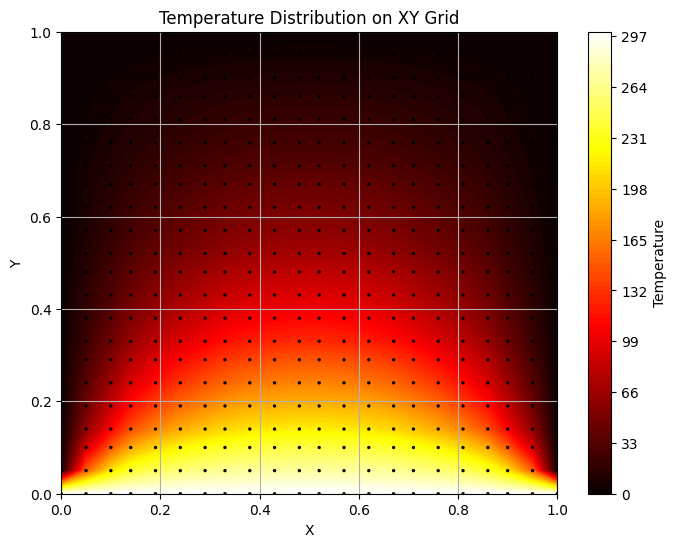

In [69]:
import matplotlib.pyplot as plt

x = [item[0] for item in final_T]
y = [item[1] for item in final_T]
z = [item[2] for item in final_T]

grid_x = numpy.unique(x)
grid_y = numpy.unique(y)
print(len(grid_x), len(z))
z_grid = numpy.transpose(numpy.array(z).reshape(len(grid_y), len(grid_x)))

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(grid_x, grid_y, z_grid, levels=100, cmap='hot')
plt.colorbar(label='Temperature')
plt.scatter(x, y, c=z, cmap='hot', edgecolor='k', s=2)  # Add scatter points for reference

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Temperature Distribution on XY Grid')
plt.grid()
plt.show()

In [ ]:
print(x)
print(grid_x)

In [70]:
df = pandas.DataFrame(final_T, columns= ["X", "Y", "Temperature (K)"])
df.to_csv(r"D:\thesis\python\2D_SteadyState_HeatEquation.csv", sep= ",", index= False)

In [3]:
df1 = pandas.read_csv(r"D:\thesis\python\output_2D.csv")
df2 = pandas.read_csv(r"D:\thesis\python\2D_SteadyState_HeatEquation.csv")

In [58]:

X, Y, TT, L2 = df1["X (m)"].to_numpy(), df1["Y (m)"].to_numpy(), df1["Temperature (K)"].to_numpy(), df1["L2 Error (K)"].to_numpy()

for id, (x,y) in enumerate(zip(X,Y)):
    X[id] = round(x,2)
    Y[id] = round(y,2)
common_points = numpy.intersect1d(X, Y)

# Reduce X, Y, TT, and L2 to the common subset
X_common = X[numpy.isin(X, common_points)]
Y_common = Y[numpy.isin(Y, common_points)]

TT_common = TT[numpy.isin(X, common_points)]
L2_common = L2[numpy.isin(X, common_points)]



140

In [30]:
z_grid = numpy.transpose(numpy.array(TT).reshape(len(Y), len(X)))

ValueError: cannot reshape array of size 140 into shape (140,140)

In [21]:
import matplotlib.pyplot as plt
# Create grid for TT and L2 values
TT_grid = grid_data.pivot(index='Y', columns='X', values='Temperature (K)')
L2_grid = grid_data.pivot(index='Y', columns='X', values='L2 Error (K)')

print(TT_grid)

X     0.00  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05        0.05  ...  \
Y                                                                       ...   
0.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
0.05   0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
0.05   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  149.168518  ...   
0.05   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
0.05   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
...    ...   ...   ...   ...   ...   ...   ...   ...   ...         ...  ...   
0.95   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
0.95   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
0.95   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
1.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN         NaN  ...   
1.00   NaN   0.0   NaN   NaN   NaN   NaN   NaN   NaN

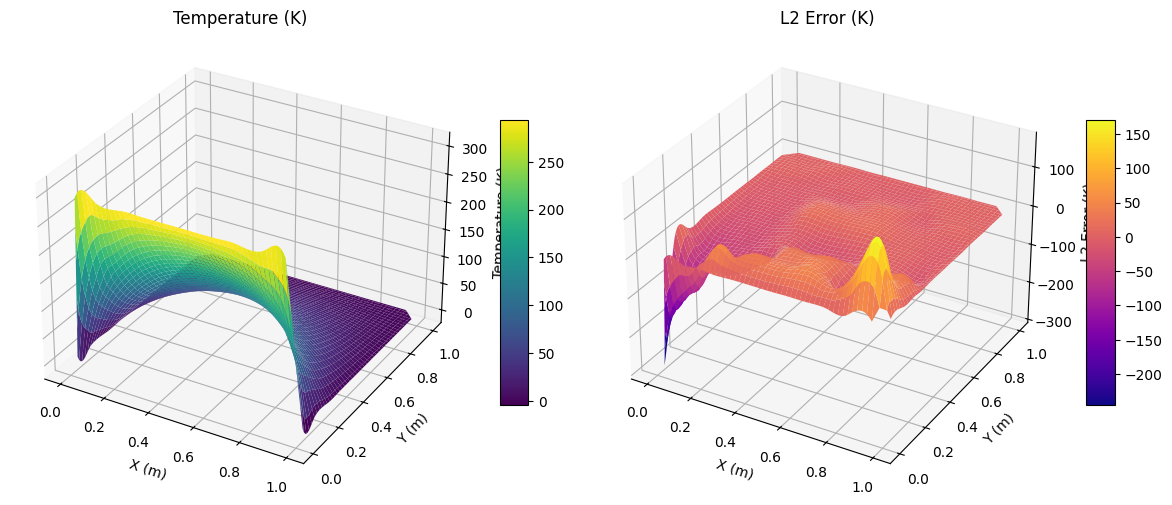

In [ ]:
import numpy as numpy
import matplotlib.pyplot as plt

# Assuming df1 is a pandas DataFrame with the columns X (m), Y (m), Temperature (K), and L2 Error (K).
# X, Y, TT, and L2 are extracted as follows:
X, Y, TT, L2 = df1["X (m)"], df1["Y (m)"], df1["Temperature (K)"], df1["L2 Error (K)"]

# Convert the data to a grid
grid_x, grid_y = numpy.meshgrid(
    numpy.unique(X), numpy.unique(Y)
)

# Reshape TT and L2 into the grid format
grid_TT = TT.values.reshape(grid_y.shape)
grid_L2 = L2.values.reshape(grid_y.shape)

# Create the plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Temperature (TT)
c1 = ax[0].contourf(grid_x, grid_y, grid_TT, cmap='viridis')
ax[0].set_title("Temperature (K)")
ax[0].set_xlabel("X (m)")
ax[0].set_ylabel("Y (m)")
fig.colorbar(c1, ax=ax[0])

# Plot L2 Error
c2 = ax[1].contourf(grid_x, grid_y, grid_L2, cmap='plasma')
ax[1].set_title("L2 Error (K)")
ax[1].set_xlabel("X (m)")
ax[1].set_ylabel("Y (m)")
fig.colorbar(c2, ax=ax[1])

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
sortedZip